In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import time
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

In [37]:
data = pd.read_csv('cleaned_data.csv', index_col=0)
x = data.iloc[:, 1:-1]
y = data.iloc[:,-1]

1500

In [21]:
x_train_and_val, x_test, y_train_and_val, y_test = train_test_split(x, y, test_size = 0.15, random_state = 1)
x_train, x_val, y_train, y_val = train_test_split(x_train_and_val, y_train_and_val, test_size = 0.15 / .85, random_state = 1)
x_train

,ect,hou,enron,com,gas,deal,meter,hpl,please,e,...,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry
1322,2,0,1,0,0,0,0,0,0,48,...,0,0,0,0,0,0,0,0,0,0
3770,2,0,0,1,0,2,1,0,0,86,...,0,0,0,0,0,0,0,0,0,0
922,1,1,0,1,0,0,0,0,1,158,...,0,0,0,0,12,0,0,0,6,0
227,1,0,0,0,0,0,0,0,0,12,...,0,0,1,0,0,0,0,0,1,0
4573,1,1,0,0,0,0,0,0,0,14,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2162,1,10,0,75,0,0,0,0,0,475,...,0,0,0,0,0,0,0,0,35,0
2509,1,0,2,0,0,0,0,2,0,6,...,0,0,0,0,0,0,0,0,0,0
3085,2,0,0,0,0,0,0,1,2,32,...,0,0,0,0,0,0,0,0,1,0
4293,1,1,0,0,3,2,0,0,0,16,...,0,0,0,0,0,0,0,0,0,0


In [38]:
maxval = 0
maxC = 0
for c in range(1,101,5):
    model = LinearSVC(max_iter = 3000, dual=False, C = c/100)
    model.fit(x_train,y_train)
    result = model.predict(x_val)
    score = accuracy_score(y_val, result)
    if score > maxval:
        maxval = score
        maxC = c / 100
    print(str(c) + ": " + str(score))

1: 0.979381443298969
6: 0.9742268041237113
11: 0.9742268041237113
16: 0.9742268041237113
21: 0.9768041237113402
26: 0.9780927835051546
31: 0.9780927835051546
36: 0.9780927835051546
41: 0.9780927835051546
46: 0.9780927835051546
51: 0.9768041237113402
56: 0.9768041237113402
61: 0.9780927835051546
66: 0.9780927835051546
71: 0.9768041237113402
76: 0.9768041237113402
81: 0.9768041237113402
86: 0.9780927835051546
91: 0.9768041237113402
96: 0.9768041237113402


In [89]:
maxval, maxC

(0.979381443298969, 0.01)

In [28]:
def FPR(arr):
    # false positive / false positive + true negative
    return arr[0][1] / (arr[0][1] + arr[0][0])

In [39]:
print("SVM Linear Kernel")
start = time.time()
model = SVC(kernel = "linear")
model.fit(x_train,y_train)
end = time.time()
print("time: ", end - start)

result = model.predict(x_val)
print("accuracy score:", accuracy_score(y_val, result))
print("area under roc:", roc_auc_score(y_val, result))
print("false positive rate", FPR(confusion_matrix(y_val, result)))

SVM Linear Kernel
time:  4.387895822525024
accuracy score: 0.9652061855670103
area under roc: 0.9591377487026881
false positive rate 0.026929982046678635


In [40]:
print("SVM with Polynomial Kernel")
start = time.time()
model = SVC(kernel = "poly")
model.fit(x_train,y_train)
end = time.time()
print("time: ", end - start)

result = model.predict(x_val)
print("accuracy score:", accuracy_score(y_val, result))
print("area under roc:", roc_auc_score(y_val, result))
print("false positive rate", FPR(confusion_matrix(y_val, result)))

SVM with Polynomial Kernel
time:  11.826582908630371
accuracy score: 0.7641752577319587
area under roc: 0.5849626587311347
false positive rate 0.003590664272890485


In [41]:
print("SVM RBF Kernel")
start = time.time()
model = SVC(kernel = "rbf")
model.fit(x_train,y_train)
end = time.time()
print("time: ", end - start)

result = model.predict(x_val)
print("accuracy score:", accuracy_score(y_val, result))
print("area under roc:", roc_auc_score(y_val, result))
print("false positive rate", FPR(confusion_matrix(y_val, result)))

SVM RBF Kernel
time:  12.597386837005615
accuracy score: 0.7989690721649485
area under roc: 0.656304567029832
false positive rate 0.01615798922800718


In [42]:
# Naive Bayesian
print("Naive Bayesian")
model = GaussianNB()
start = time.time()
model.fit(x_train,y_train)
end = time.time()
print("time:", end - start)
result = model.predict(x_val)
print("accuracy score:", accuracy_score(y_val, result))
print("area under roc:", roc_auc_score(y_val, result))
print("false positive rate", FPR(confusion_matrix(y_val, result)))

Naive Bayesian
time: 0.2779510021209717
accuracy score: 0.970360824742268
area under roc: 0.9696556077486207
false positive rate 0.02872531418312388


In [182]:
from sklearn.neural_network import MLPClassifier

# adam solver
mlp = MLPClassifier(hidden_layer_sizes=(8,8), activation='relu', solver='adam', max_iter=500, momentum = 0)

mlp.fit(x_train,y_train)

result5 = mlp.predict(x_val)


In [177]:
# sgd solver
mlp2 = MLPClassifier(hidden_layer_sizes=(8,8), activation='relu', solver='sgd', max_iter = 500, learning_rate_init = 0.001)

mlp2.fit(x_train,y_train)

result6 = mlp2.predict(x_val)


In [137]:
# baseline solver
mlp3 = MLPClassifier(hidden_layer_sizes=(8,8), activation='relu', solver='lbfgs', max_iter=500)

mlp3.fit(x_train,y_train)

result7 = mlp3.predict(x_val)

In [181]:
print("adam solver:", accuracy_score(y_val, result5))
print("regular sgd solver:", accuracy_score(y_val, result6))
print("traditional bp solver:", accuracy_score(y_val, result7))

adam solver: 0.9871134020618557
regular sgd solver: 0.9652061855670103
traditional bp solver: 0.9729381443298969


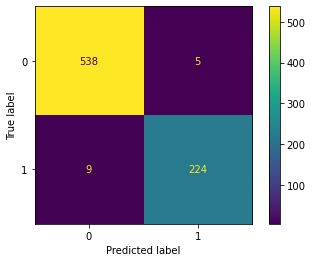

In [168]:
from sklearn.metrics import plot_confusion_matrix
plot_confusion_matrix(mlp_full, x_test, y_test)